In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path    

In [2]:
IN_KAGGLE = os.path.exists('/kaggle/input') 

if IN_KAGGLE :
    # change that to name of folder on kaggle
    DATA_DIR_TRAIN = Path('/kaggle/input/house-prices-advanced-regression-techniques')
    DATA_DIR_TEST = Path('/kaggle/input/house-prices-advanced-regression-techniques')

else :
    # Path.cwd() <> current working directory
    # parent() <> undo a folder 
    DATA_DIR_TRAIN = Path.cwd().parent / 'datasets'  / 'processed' 
    DATA_DIR_TEST = Path.cwd().parent / 'datasets'  / 'processed' 

train_data = pd.read_csv( DATA_DIR_TRAIN / 'cleaned_train_data.csv')
test_data = pd.read_csv( DATA_DIR_TEST / 'cleaned_test_data.csv')

train_data.shape , test_data.shape

((1458, 76), (1459, 75))

In [3]:
def summary(df):
    pd.set_option('display.max.rows' , None)
    pd.set_option('display.max.columns' , None)

    summary_df = pd.DataFrame({ 'Dtype': df.dtypes , 
                               'Count_Null' : df.isnull().sum() , 
                               'Null_Percent' : ( df.isnull().sum()  / len(df)) * 100 ,
                               'Unique' : df.nunique()
                              })

    return summary_df

summary(train_data)


,Dtype,Count_Null,Null_Percent,Unique
Id,int64,0,0.0,1458
MSSubClass,int64,0,0.0,15
MSZoning,str,0,0.0,5
LotFrontage,float64,0,0.0,110
LotArea,int64,0,0.0,1071
Street,str,0,0.0,2
LotShape,str,0,0.0,4
LandContour,str,0,0.0,4
Utilities,str,0,0.0,2
LotConfig,str,0,0.0,5


In [4]:
test_data.isnull().sum()[test_data.isnull().sum() > 0 ] ,
train_data.isnull().sum()[train_data.isnull().sum() > 0 ]

Series([], dtype: int64)

#### Features Extraction

In [5]:
# House's Age while Selling
train_data['HouseAge'] = train_data['YrSold'] - train_data['YearBuilt']
test_data['HouseAge'] = test_data['YrSold'] - test_data['YearBuilt']

#-------------------------------------------------------------------------------------

# Total House's Area
train_data['TotalSF'] = train_data['TotalBsmtSF'] + train_data['1stFlrSF'] + train_data['2ndFlrSF'] 
test_data['TotalSF'] = test_data['TotalBsmtSF'] + test_data['1stFlrSF'] + test_data['2ndFlrSF'] 

#-------------------------------------------------------------------------------------

# Total Bathrooms in the house
train_data['TotalBathrooms'] = train_data['FullBath'] + 0.5 * train_data[
'HalfBath'] + train_data['BsmtFullBath'] + 0.5 * train_data['BsmtHalfBath']

test_data['TotalBathrooms'] = test_data['FullBath'] + 0.5 * test_data[
'HalfBath'] + test_data['BsmtFullBath'] + 0.5 * test_data['BsmtHalfBath']

#-------------------------------------------------------------------------------------

# Total External Area related to the house
train_data['TotalPorchSF'] = train_data['OpenPorchSF'] +  train_data[
'EnclosedPorch'] + train_data['3SsnPorch'] +  train_data['ScreenPorch'] + train_data['WoodDeckSF']

test_data['TotalPorchSF'] = test_data['OpenPorchSF'] +  test_data[
'EnclosedPorch'] + test_data['3SsnPorch'] +  test_data['ScreenPorch'] + test_data['WoodDeckSF']


#-------------------------------------------------------------------------------------
# Total Rooms without Bedrooms
train_data['NonBedroomRooms'] = train_data['TotRmsAbvGrd'] - train_data['BedroomAbvGr']
test_data['NonBedroomRooms'] = test_data['TotRmsAbvGrd'] - test_data['BedroomAbvGr']



In [6]:
# Has Garage Or No 
# the condition produces True or False if True it converts into 1 , False into 0
train_data['HasGarage'] = ( train_data['GarageArea']  > 0 ).astype(int)
test_data['HasGarage'] = ( test_data['GarageArea']  > 0 ).astype(int)

#----------------------------------------------------------------------------------

# Has Basement Or No 
train_data['HasBasement'] = (train_data['TotalBsmtSF'] > 0 ).astype(int)
test_data['HasBasement'] = (test_data['TotalBsmtSF'] > 0 ).astype(int)

#----------------------------------------------------------------------------------

# Has FirePlace Or No 
train_data['HasFirePlace'] = (train_data['Fireplaces'] > 0 ).astype(int)
test_data['HasFirePlace'] = (test_data['Fireplaces'] > 0 ).astype(int)

#----------------------------------------------------------------------------------

# Has Pool Or No 
train_data['HasPool'] = (train_data['PoolArea'] > 0 ).astype(int)
test_data['HasPool'] = (test_data['PoolArea'] > 0 ).astype(int)

In [7]:
# How Many Years since The Last Remodel
train_data['YearsSinceRemodel'] = ( train_data['YrSold'] - train_data['YearRemodAdd'] )
test_data['YearsSinceRemodel'] = ( test_data['YrSold'] - test_data['YearRemodAdd'] )

#----------------------------------------------------------------------------------------

# One Car's Average In The Garage

train_data['GarageAreaPerCar'] = (train_data['GarageArea'] / train_data[
                                     'GarageCars'].replace( 0 , np.nan)).fillna(0)

test_data['GarageAreaPerCar'] = ( test_data['GarageArea'] / test_data[
                                     'GarageCars'].replace( 0 , np.nan) ).fillna(0)

train_data['GarageAreaPerCar'].isnull().sum() , test_data['GarageAreaPerCar'].isnull().sum()

#----------------------------------------------------------------------------------------

# Garage Age
train_data['GarageAge'] = train_data['YrSold'] - train_data['GarageYrBlt']
test_data['GarageAge'] = test_data['YrSold'] - test_data['GarageYrBlt']

In [8]:
# Quality and Area of House
train_data['QualityArea'] = ( train_data['OverallQual'] * train_data['GrLivArea'] )
test_data['QualityArea'] = ( test_data['OverallQual'] * test_data['GrLivArea'] )

# ------------------------------------------------------------------------------------------

# Average Of Area Per Room
train_data['TotalSF_per_Room'] = ( train_data['TotalSF'] / train_data['TotRmsAbvGrd'] )
test_data['TotalSF_per_Room'] = ( test_data['TotalSF'] / test_data['TotRmsAbvGrd'] )

In [9]:
print(f'Train Shape After FE : {train_data.shape}')
print(f'Test Shape After FE : {test_data.shape}')

Train Shape After FE : (1458, 90)
Test Shape After FE : (1459, 89)


In [10]:
new_features = ['HouseAge','TotalSF','TotalBathrooms','TotalPorchSF',
                'NonBedroomRooms','HasGarage','HasBasement','HasFirePlace',
                'HasPool' , 'YearsSinceRemodel' , 'GarageAreaPerCar' , 'GarageAge' ,
                'QualityArea' , 'TotalSF_per_Room'
               ]

train_data[new_features].describe()

,HouseAge,TotalSF,TotalBathrooms,TotalPorchSF,NonBedroomRooms,HasGarage,HasBasement,HasFirePlace,HasPool,YearsSinceRemodel,GarageAreaPerCar,GarageAge,QualityArea,TotalSF_per_Room
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,36.598080,2557.150206,2.207476,180.810014,3.644719,0.944444,0.974623,0.526749,0.004115,22.982167,256.599337,139.266804,9616.458162,396.827155
std,30.240565,774.109803,0.781341,156.120838,1.217569,0.229140,0.157322,0.499455,0.064040,20.636501,87.211306,453.996042,4948.957098,89.730236
min,0.000000,334.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,149.714286
25%,8.000000,2008.500000,2.000000,45.000000,3.000000,1.000000,1.000000,0.000000,0.000000,4.000000,225.333333,7.000000,5780.000000,341.357143
50%,35.000000,2473.000000,2.000000,164.000000,4.000000,1.000000,1.000000,1.000000,0.000000,14.000000,263.500000,30.000000,8817.000000,385.788889
75%,54.000000,3002.250000,2.500000,265.000000,4.000000,1.000000,1.000000,1.000000,0.000000,41.000000,289.833333,50.000000,12142.500000,447.250000
max,136.000000,6872.000000,6.000000,1027.000000,9.000000,1.000000,1.000000,1.000000,1.000000,60.000000,924.000000,2010.000000,44760.000000,747.500000


### Visualization

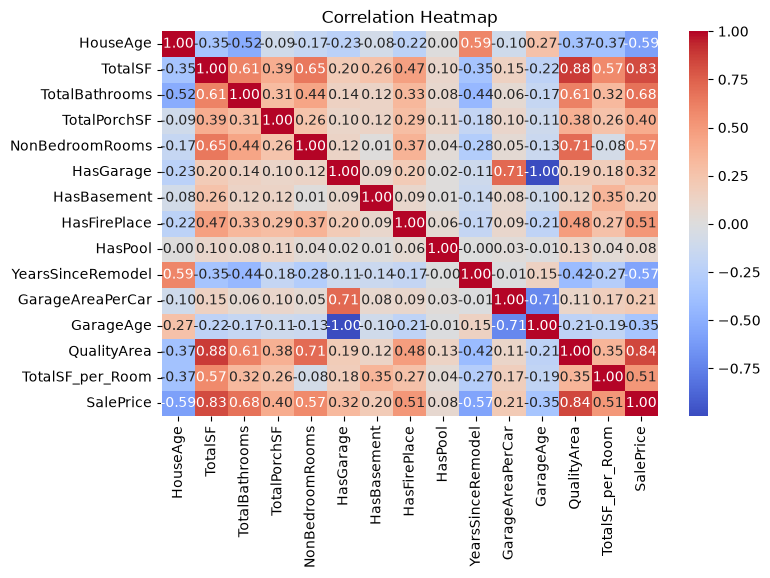

In [11]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    train_data[new_features + ['SalePrice']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
            )

plt.title('Correlation Heatmap')
plt.show()

In [12]:
num_features = train_data.select_dtypes(include=np.number)
num_features.shape

(1458, 52)

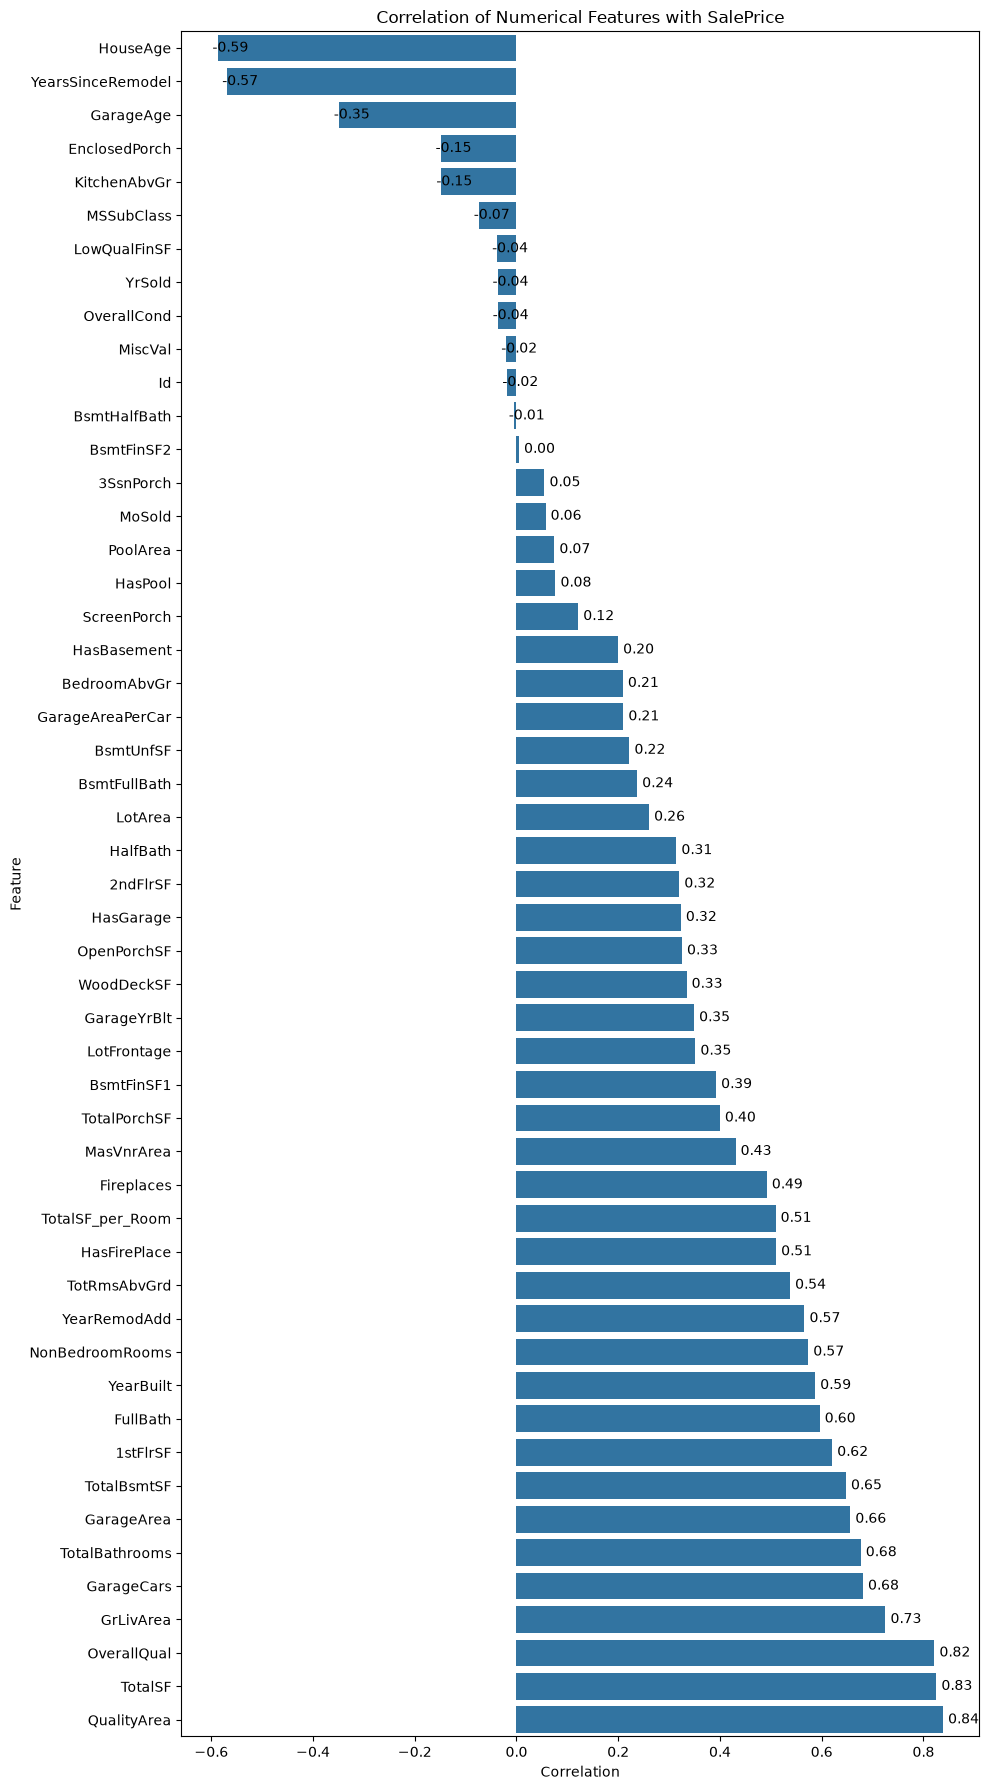

In [13]:
num_data = train_data.select_dtypes(include=np.number)

corr_with_price = (
    num_data.corr()['SalePrice']
    .drop('SalePrice')
    .sort_values()
)

plt.figure(figsize=(10, 18))

ax = sns.barplot(
    x=corr_with_price.values,
    y=corr_with_price.index
)

for i, value in enumerate(corr_with_price.values):
    ax.text(
        value + 0.01 if value >= 0 else value - 0.01,
        i,
        f'{value:.2f}',
        va='center'
    )

plt.title('Correlation of Numerical Features with SalePrice')
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [14]:
corr_matrix = train_data.select_dtypes(include=np.number).corr()

high_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    high_corr.stack()
    .sort_values(ascending=False)
)

high_corr_pairs[high_corr_pairs > 0.80]

GarageYrBlt   HasGarage          0.998603
PoolArea      HasPool            0.991075
GrLivArea     QualityArea        0.923597
Fireplaces    HasFirePlace       0.902581
GarageCars    GarageArea         0.887304
TotalSF       QualityArea        0.875249
TotRmsAbvGrd  NonBedroomRooms    0.870967
GrLivArea     TotalSF            0.866386
SalePrice     QualityArea        0.838445
GrLivArea     TotRmsAbvGrd       0.829498
SalePrice     TotalSF            0.825326
OverallQual   SalePrice          0.821405
              QualityArea        0.821358
TotalBsmtSF   TotalSF            0.806400
              1stFlrSF           0.803830
dtype: float64

In [15]:
train_data = train_data.drop(['HasPool','HasFirePlace'] , axis = 1 )
test_data = test_data.drop(['HasPool','HasFirePlace'] , axis = 1 )

### One Hot Encoder

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectPercentile, f_regression

In [17]:

TARGET = "SalePrice"

X_train = train_data.drop(columns=[TARGET])
y_train = train_data[TARGET]

X_test = test_data.copy()  

In [18]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols   = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'SaleType', 'SaleCondition']
Numerical columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnP

C:\Users\B-UNIT\AppData\Local\Temp\ipykernel_16732\3461495758.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [19]:

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_cat_encoded = encoder.fit_transform(X_train[categorical_cols])
test_cat_encoded  = encoder.transform(X_test[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)

train_cat_df = pd.DataFrame(train_cat_encoded, columns=encoded_cols, index=X_train.index)
test_cat_df  = pd.DataFrame(test_cat_encoded, columns=encoded_cols, index=X_test.index)

In [20]:
train_cat_df.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_Missing,BsmtQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Missing,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Missing,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Missing,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Missing,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_Missing,GarageFinish_Fin,GarageFinish_Missing,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Missing,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Missing,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,PoolQC_Ex,PoolQC_Fa,PoolQC_Gd,PoolQC_Missing,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondit

In [21]:
X_train_final = pd.concat([X_train[numerical_cols].reset_index(drop=True),
                            train_cat_df.reset_index(drop=True)], axis=1)

X_test_final = pd.concat([X_test[numerical_cols].reset_index(drop=True),
                           test_cat_df.reset_index(drop=True)], axis=1)


print("Shape after encoding - train:", X_train_final.shape)
print("Shape after encoding - test:", X_test_final.shape)

Shape after encoding - train: (1458, 291)
Shape after encoding - test: (1459, 291)


#### Features Selection

In [22]:

# f_regression <> aproperiate bacause the price is continuous numerical

selector = SelectPercentile(score_func=f_regression, percentile= 80 )
selector.fit(X_train_final, y_train)

selected_mask = selector.get_support() # produces True or False
selected_columns = X_train_final.columns[selected_mask]


X_train_selected = X_train_final[selected_columns]
X_test_selected  = X_test_final[selected_columns]

print(f"Original Columns  : {X_train_final.shape[1]} Columns")
print(f"Columns  with selected 80% of features  : {len(selected_columns)} Columns")


Original Columns  : 291 Columns
Columns  with selected 80% of features  : 232 Columns


In [23]:

train_final = X_train_selected.reset_index(drop=True).copy()
train_final["SalePrice"] = y_train.reset_index(drop=True)

DIR = '../datasets/processed/'

train_final.to_csv(os.path.join( DIR , "final_train.csv"), index=False )

X_test_selected.to_csv(os.path.join( DIR , "final_test.csv"), index=False )

print(f"final_train shape : {train_final.shape}")
print(f"final_test  shape : {X_test_selected.shape}")


final_train shape : (1458, 233)
final_test  shape : (1459, 232)
